# Laboratorio 4 · Parte 2
Pablo Cabrera · Luis Mendoza. Este notebook usa funciones de `src` y artefactos reproducibles; no contiene credenciales.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import pandas as pd
from src.parte2 import build_dataset, train_random, evaluate_validations
from src.ml_features import predictor_audit, strict_feature_columns

## Ejercicios 1–3 · Preparación, respuesta y predictores
La respuesta es `proxy_chl >= 10 µg/L`. No es una medición in situ ni de toxicidad. Se excluyen NDCI, clorofila, B04, B05, NDVI, FAI, coordenadas y lago del modelo principal.

In [2]:
path = ROOT/'outputs/parte2/data/observations_master.parquet'
data = pd.read_parquet(path) if path.exists() else build_dataset()
display(data.shape, data.dtypes.to_frame('dtype'), data.isna().mean().to_frame('missing_fraction'))
display(data.groupby(['lake','date','alta_presencia']).size().rename('n').reset_index())
display(predictor_audit())

(3190331, 31)

,dtype
B02,float64
B03,float64
B04,float64
B05,float64
B07,float64
B08,float64
B8A,float64
B11,float64
B12,float64
ndvi,float64


,missing_fraction
B02,0.0
B03,0.0
B04,0.0
B05,0.0
B07,0.0
B08,0.0
B8A,0.0
B11,0.0
B12,0.0
ndvi,0.0


,lake,date,alta_presencia,n
0,Amatitlan,2025-01-28,0,36477
1,Amatitlan,2025-01-28,1,22
2,Amatitlan,2025-04-15,0,35895
3,Amatitlan,2025-04-15,1,251
4,Amatitlan,2025-04-28,0,33402
5,Amatitlan,2025-04-28,1,2688
6,Amatitlan,2025-11-24,0,35633
7,Amatitlan,2025-11-24,1,733
8,Amatitlan,2026-01-08,0,34066
9,Amatitlan,2026-01-08,1,2561


,variable,permitido_modelo_principal,razon
0,chl,False,transformación directa de NDCI y fuente de y
1,ndci,False,fuente directa del proxy continuo
2,alta_presencia,False,variable respuesta
3,B04,False,componente directo de NDCI; también de NDVI y FAI
4,B05,False,componente directo de NDCI
5,ndvi,False,comparte B04 con NDCI; exclusión conservadora
6,fai,False,comparte B04 con NDCI; exclusión conservadora
7,lon/lat/x_utm/y_utm,False,puede memorizar lago o zonas; solo agrupación/...
8,lake,False,identifica dominio; solo segmentación y experi...
9,B02,True,no participa directamente en NDCI según el lin...


## Ejercicios 4–5 · Modelos y evaluación 70/30
El test común permanece intacto. La búsqueda pequeña usa PR-AUC exclusivamente dentro de entrenamiento.

In [3]:
metrics_path = ROOT/'outputs/parte2/metrics/random_metrics.csv'
random_results = pd.read_csv(metrics_path) if metrics_path.exists() else train_random(data)
display(random_results)

,strategy,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,best_params
0,random_70_30,logistic_regression,0.988437,0.991616,0.546040,0.994886,0.705092,0.998760,0.923400,932803,10999,68,13230,"{""model__C"": 1.0}"
1,random_70_30,random_forest,0.997540,0.942258,0.934148,0.885396,0.909119,0.998535,0.972633,942972,830,1524,11774,"{""model__max_depth"": null, ""model__min_samples..."
2,random_70_30,hist_gradient_boosting,0.997520,0.954073,0.911853,0.909385,0.910617,0.998776,0.971880,942633,1169,1205,12093,"{""model__l2_regularization"": 0.0, ""model__lear..."


## Ejercicios 6–7 y rúbrica temporal · Validación espacial, temporal y entre lagos
Los bloques completos nunca cruzan folds. Las últimas dos fechas completas por lago forman el test temporal. Los experimentos A→B y B→A no usan el destino para ajuste.

In [4]:
validation_path = ROOT/'outputs/parte2/metrics/validation_metrics_by_fold.csv'
validation_results = pd.read_csv(validation_path) if validation_path.exists() else evaluate_validations(data)
display(validation_results)
display(pd.read_csv(ROOT/'outputs/parte2/tables/temporal_split.csv'))

,strategy,fold,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,spatial,1,logistic_regression,0.981953,0.986404,0.434774,0.990983,0.604386,0.998780,0.930177,617461,11430,80,8792
1,spatial,1,random_forest,0.997137,0.914483,0.959202,0.829463,0.889628,0.998275,0.972117,628578,313,1513,7359
2,spatial,1,hist_gradient_boosting,0.997118,0.919085,0.948025,0.838819,0.890085,0.999468,0.970897,628483,408,1430,7442
3,spatial,2,logistic_regression,0.987986,0.990883,0.534344,0.993862,0.695016,0.998260,0.874001,622337,7620,54,8744
4,spatial,2,random_forest,0.996424,0.909760,0.910926,0.820641,0.863430,0.996583,0.945982,629251,706,1578,7220
5,spatial,2,hist_gradient_boosting,0.996283,0.923586,0.877350,0.848829,0.862854,0.998638,0.938651,628913,1044,1330,7468
6,spatial,3,logistic_regression,0.990627,0.993299,0.604235,0.996049,0.752176,0.999256,0.965561,622948,5944,36,9075
7,spatial,3,random_forest,0.997588,0.954698,0.919734,0.910548,0.915118,0.999281,0.973314,628168,724,815,8296
8,spatial,3,hist_gradient_boosting,0.997434,0.955215,0.908862,0.911755,0.910306,0.999420,0.965478,628059,833,804,8307
9,spatial,4,logistic_regression,0.987712,0.990128,0.528988,0.992611,0.690168,0.998279,0.888100,621472,7775,65,8732


,lake,train_dates,test_dates
0,Atitlan,"2025-01-18,2025-04-13,2025-05-13,2025-07-17,20...","2026-04-28,2026-07-22"
1,Amatitlan,"2025-01-28,2025-04-15,2025-04-28,2025-11-24,20...","2026-04-28,2026-06-19"


## Ejercicios 8–9 · Interpretabilidad y mapas
La importancia por permutación y SHAP se calculan sobre datos no usados en ajuste. Los mapas reconstruyen únicamente celdas observadas, con una escala común.

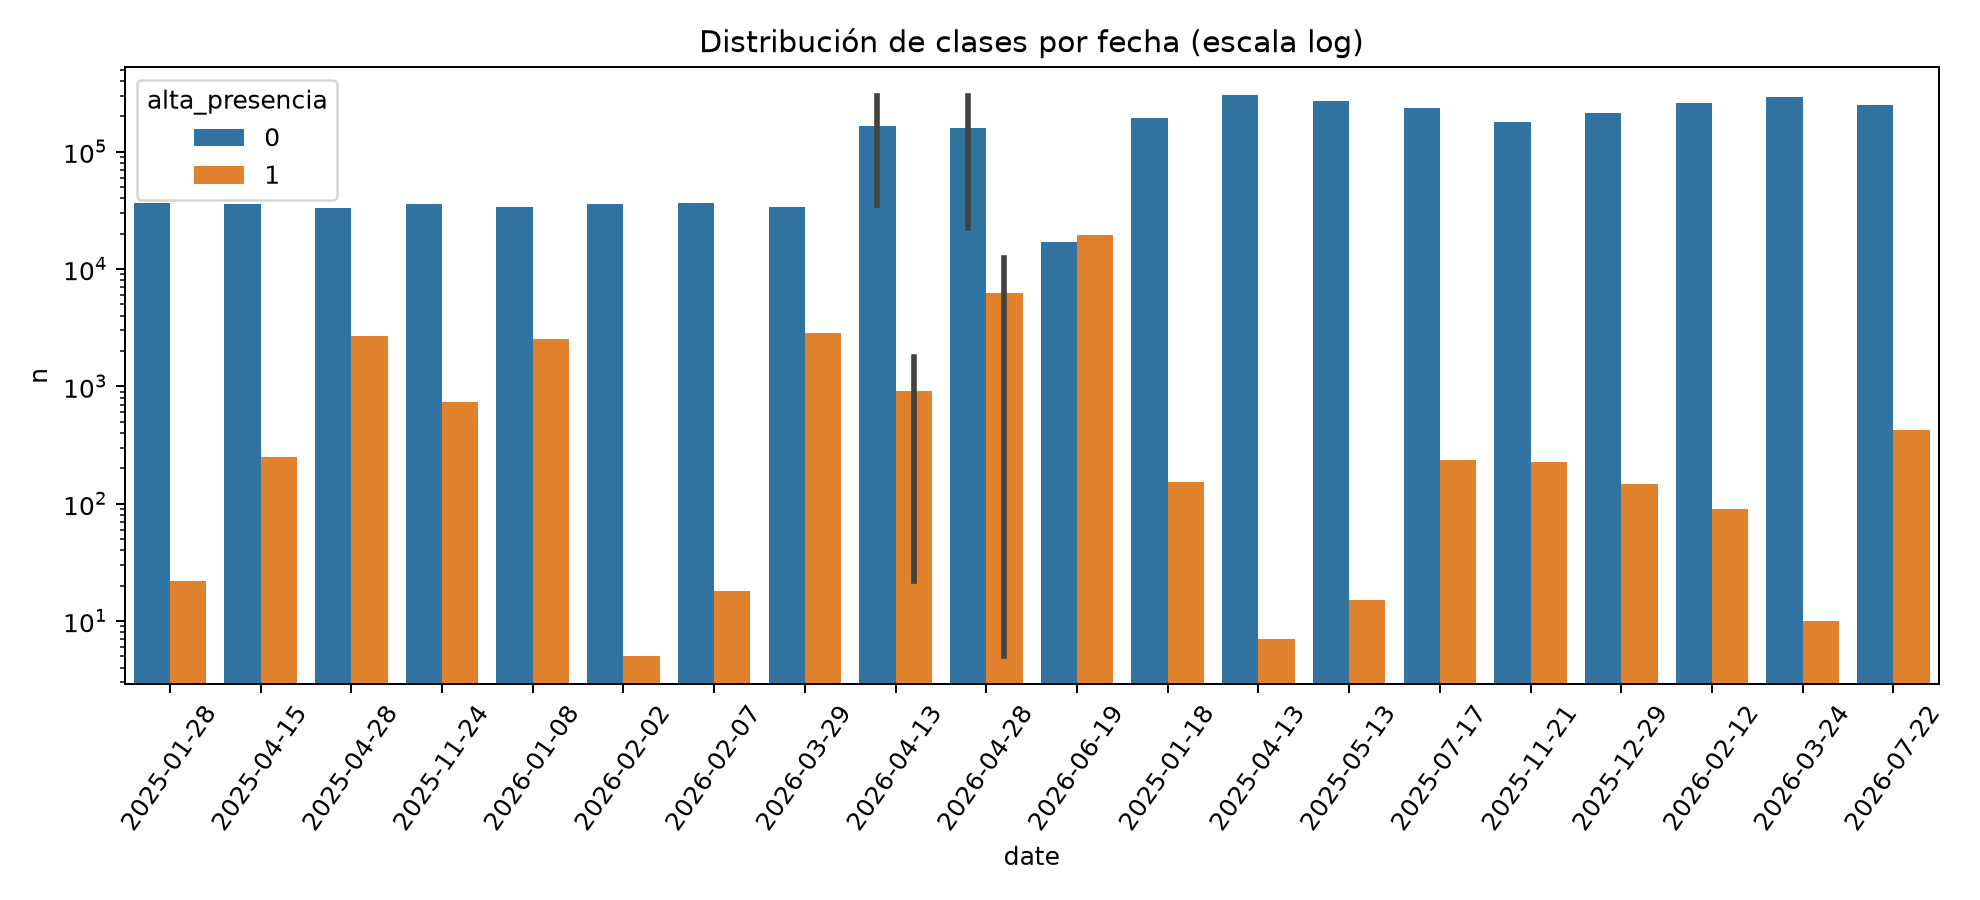

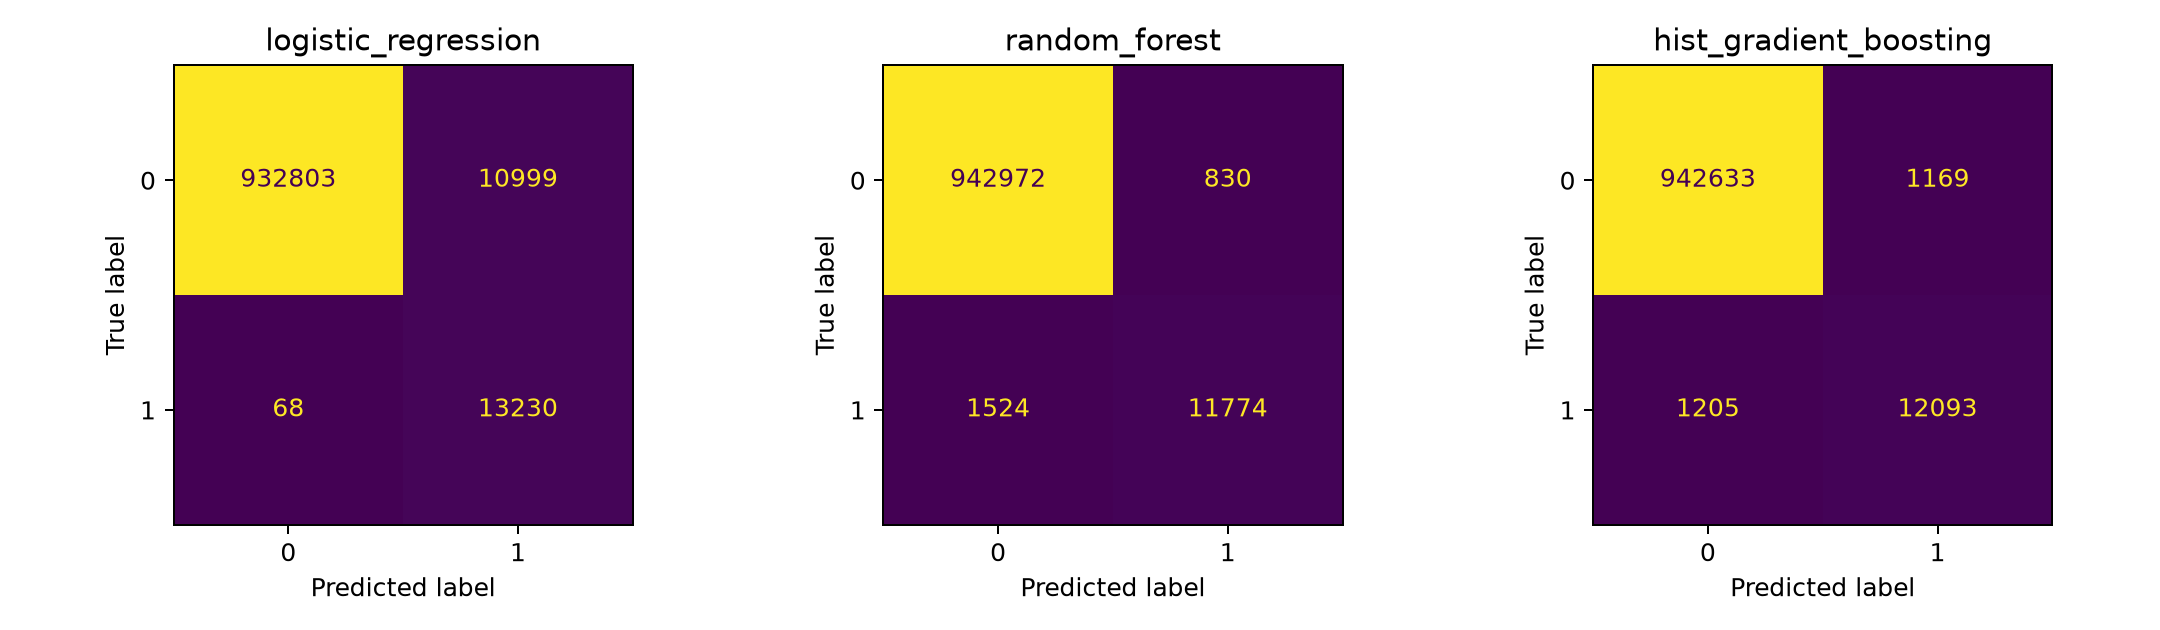

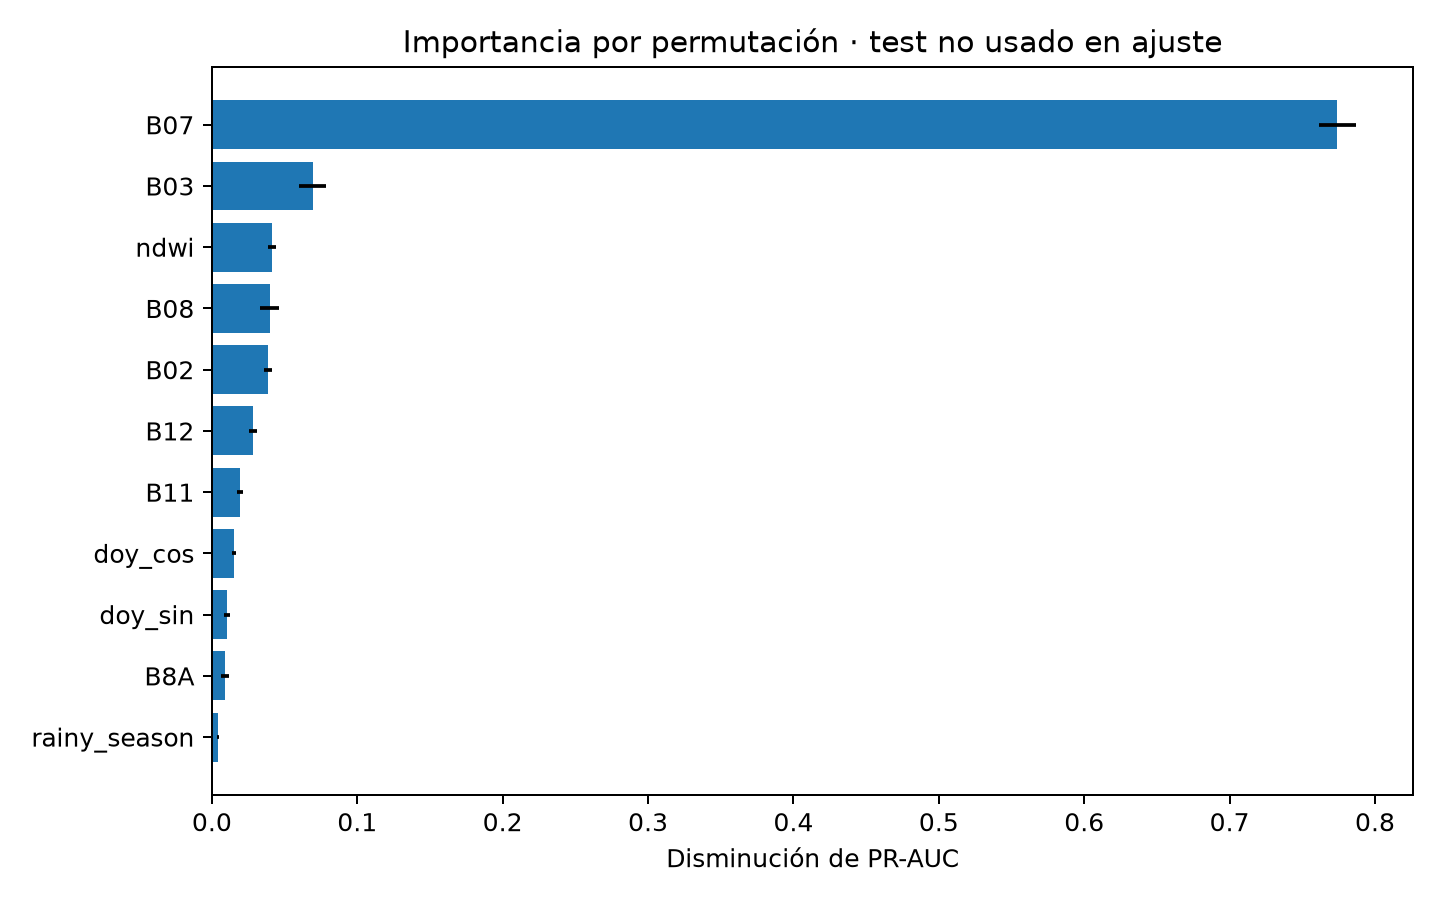

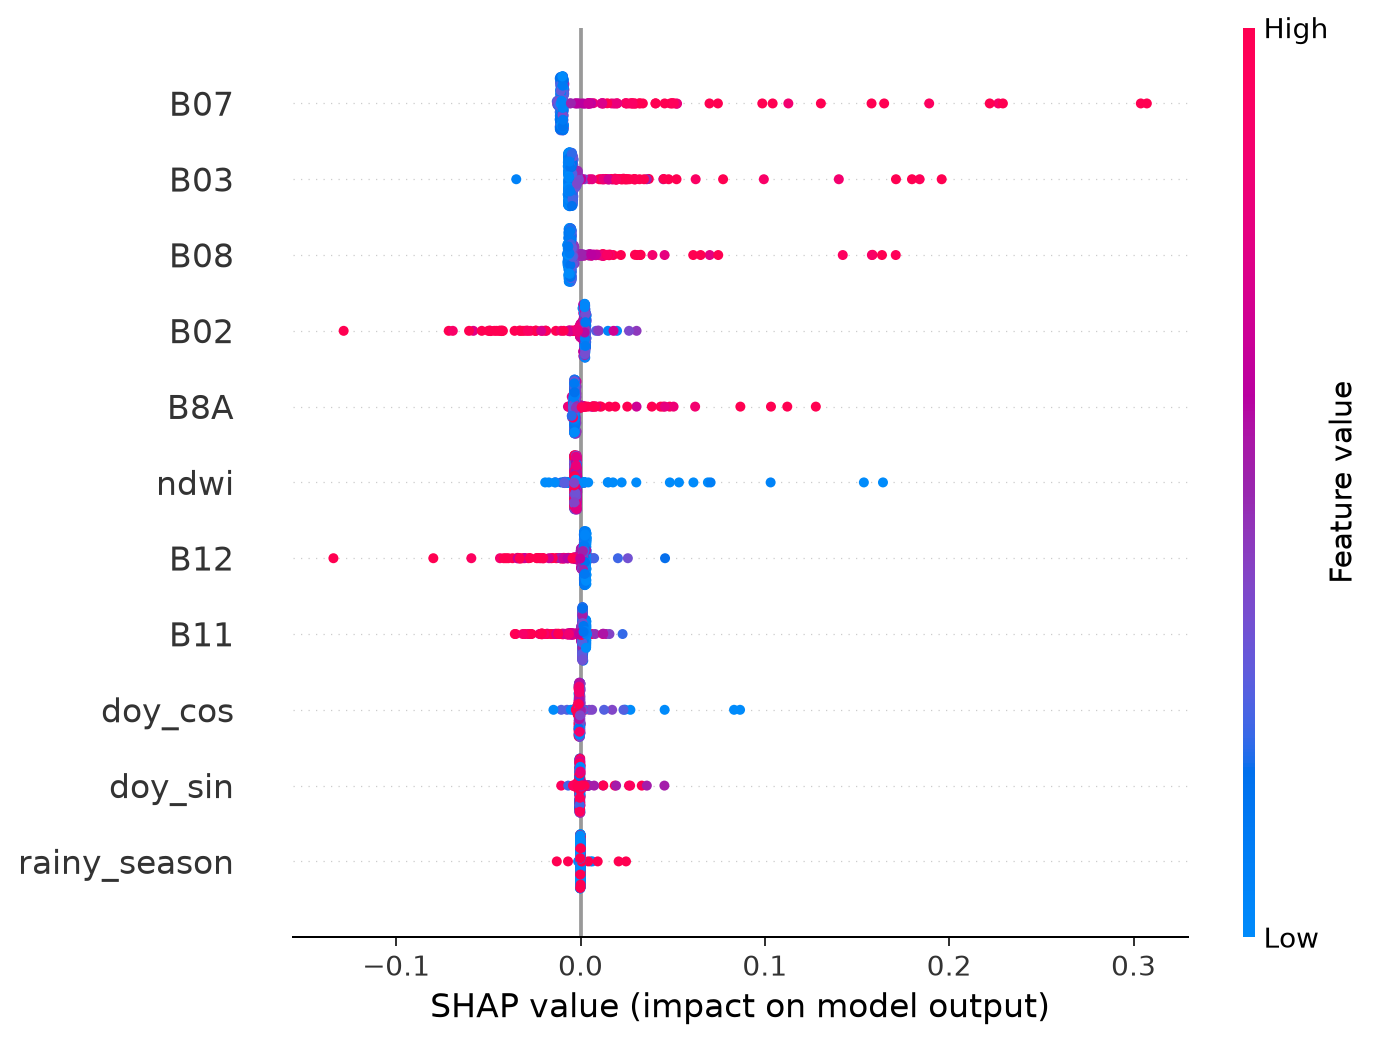

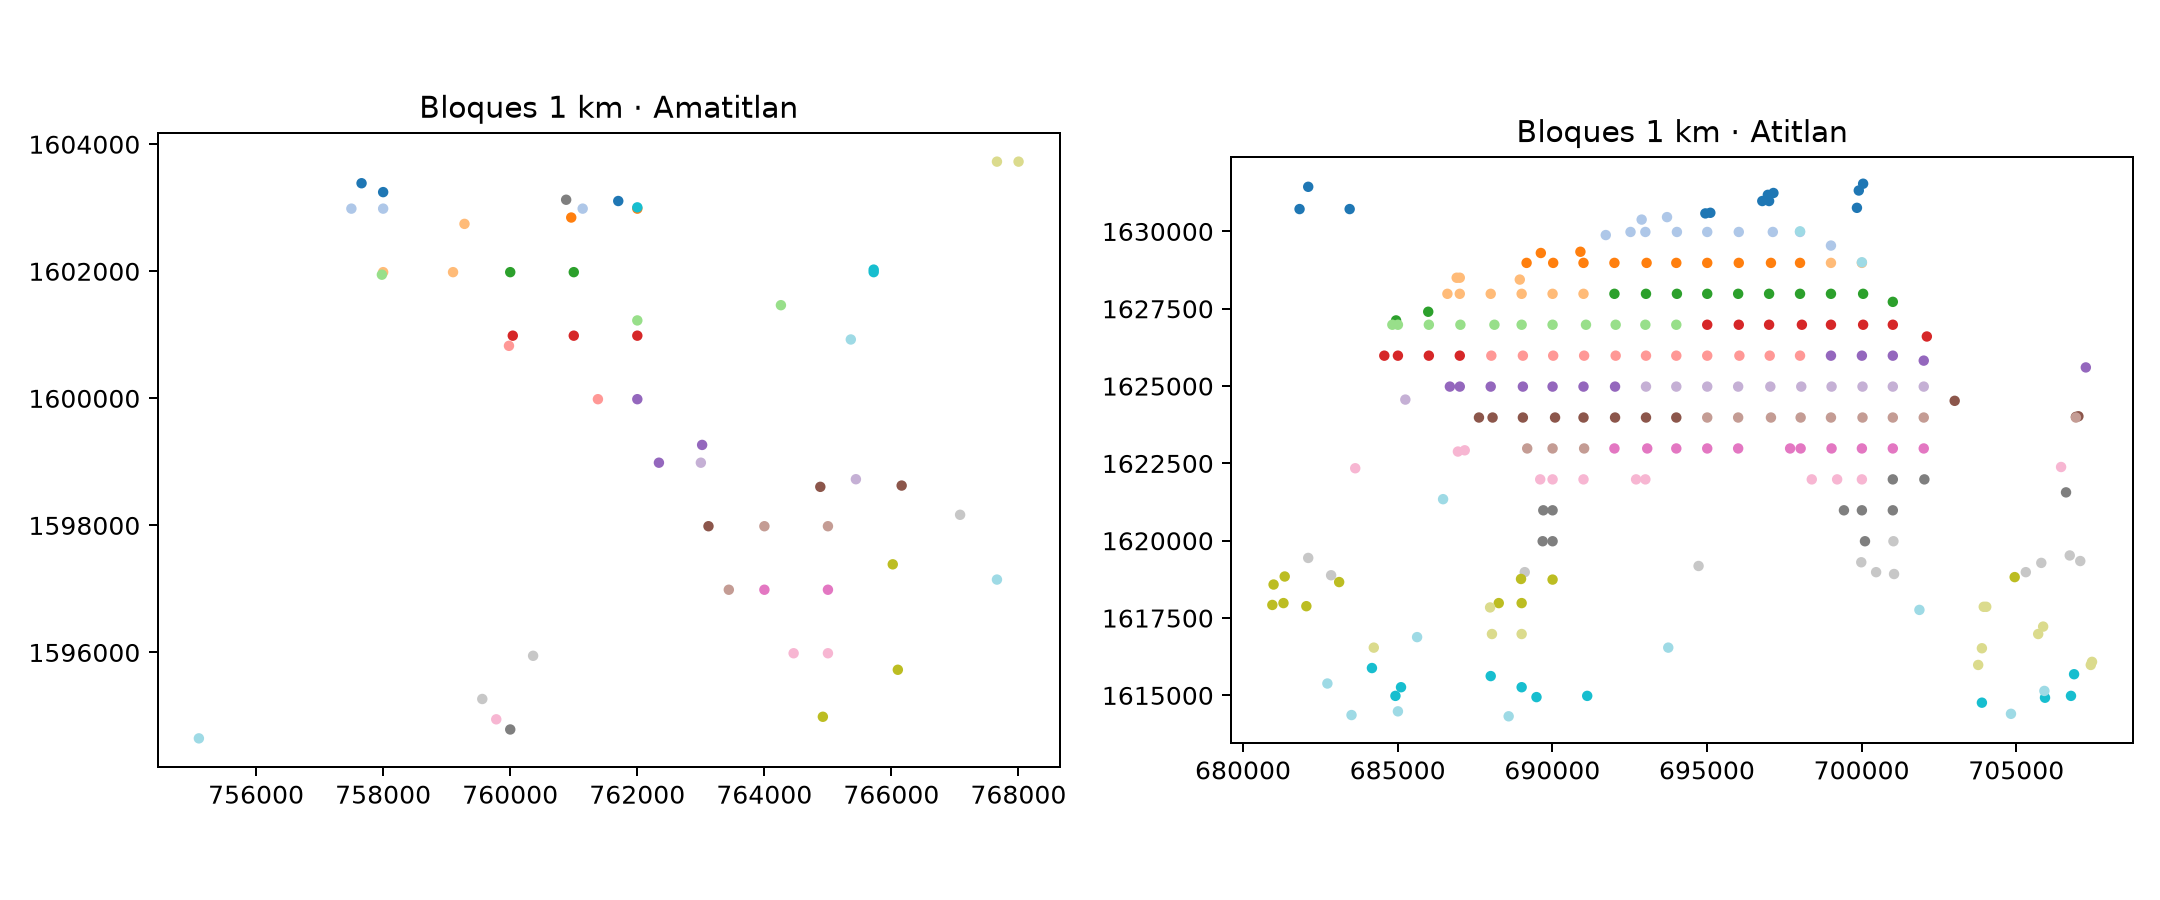

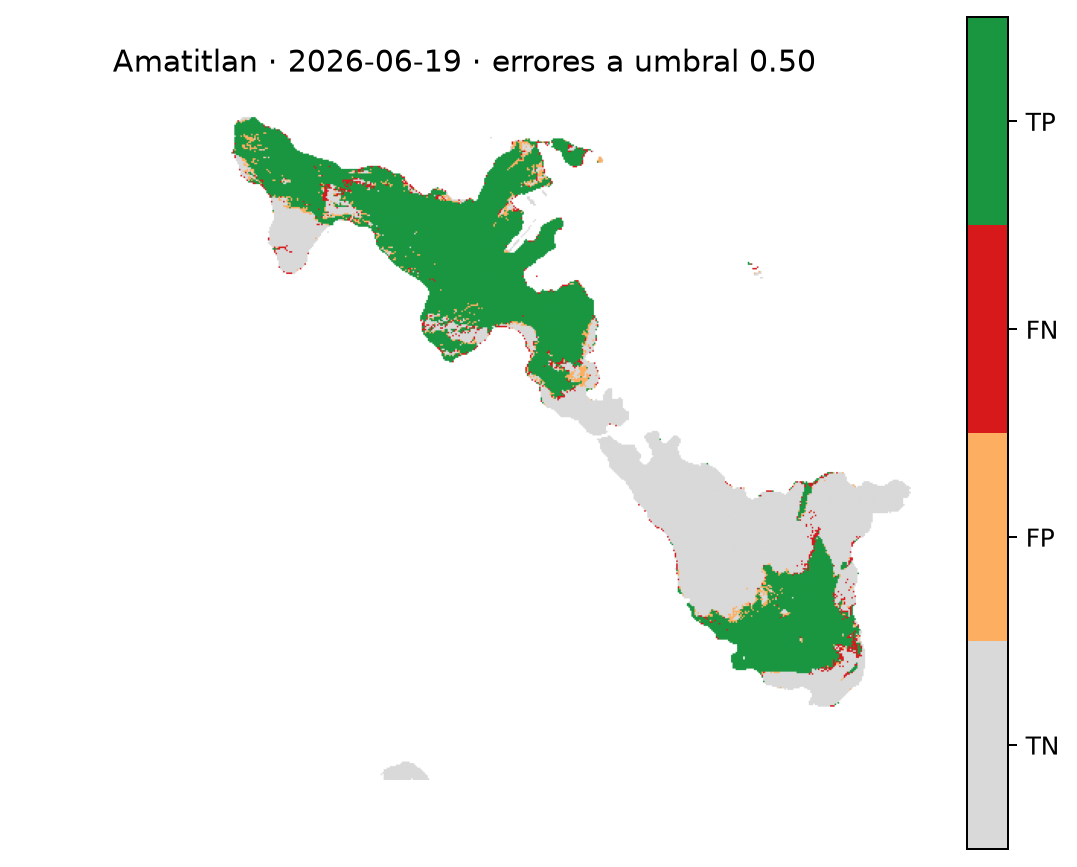

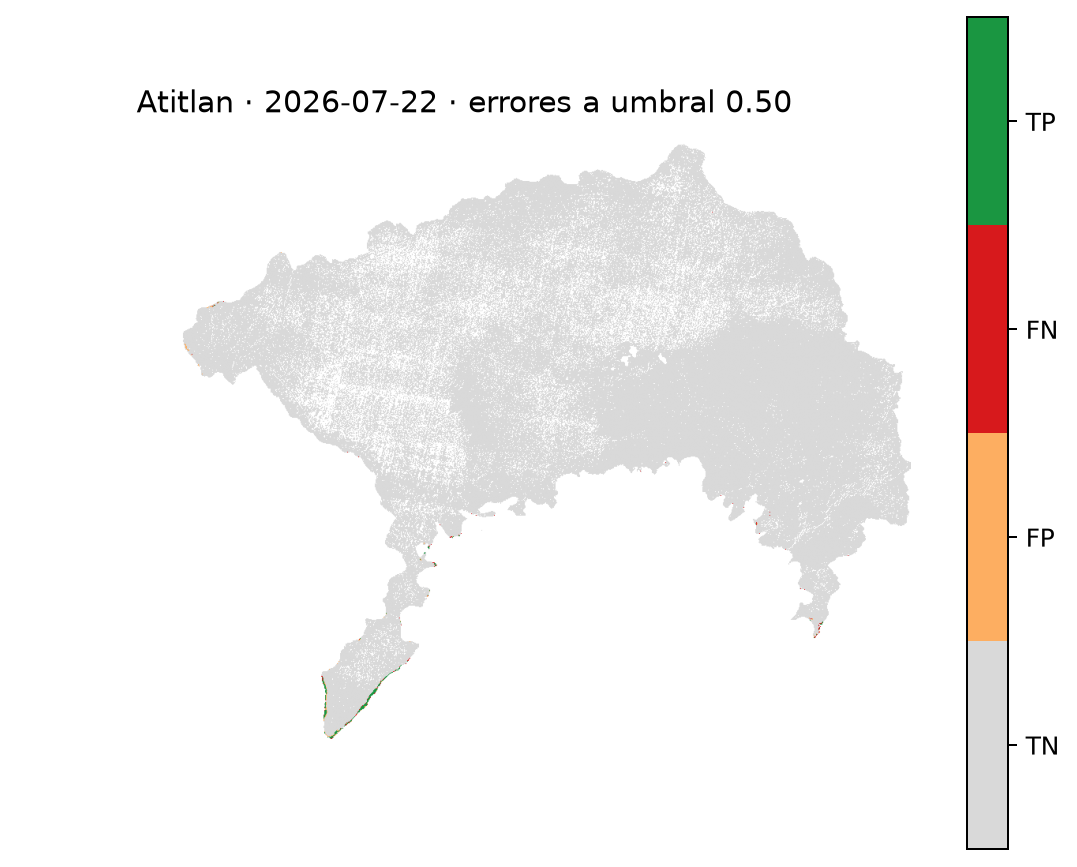

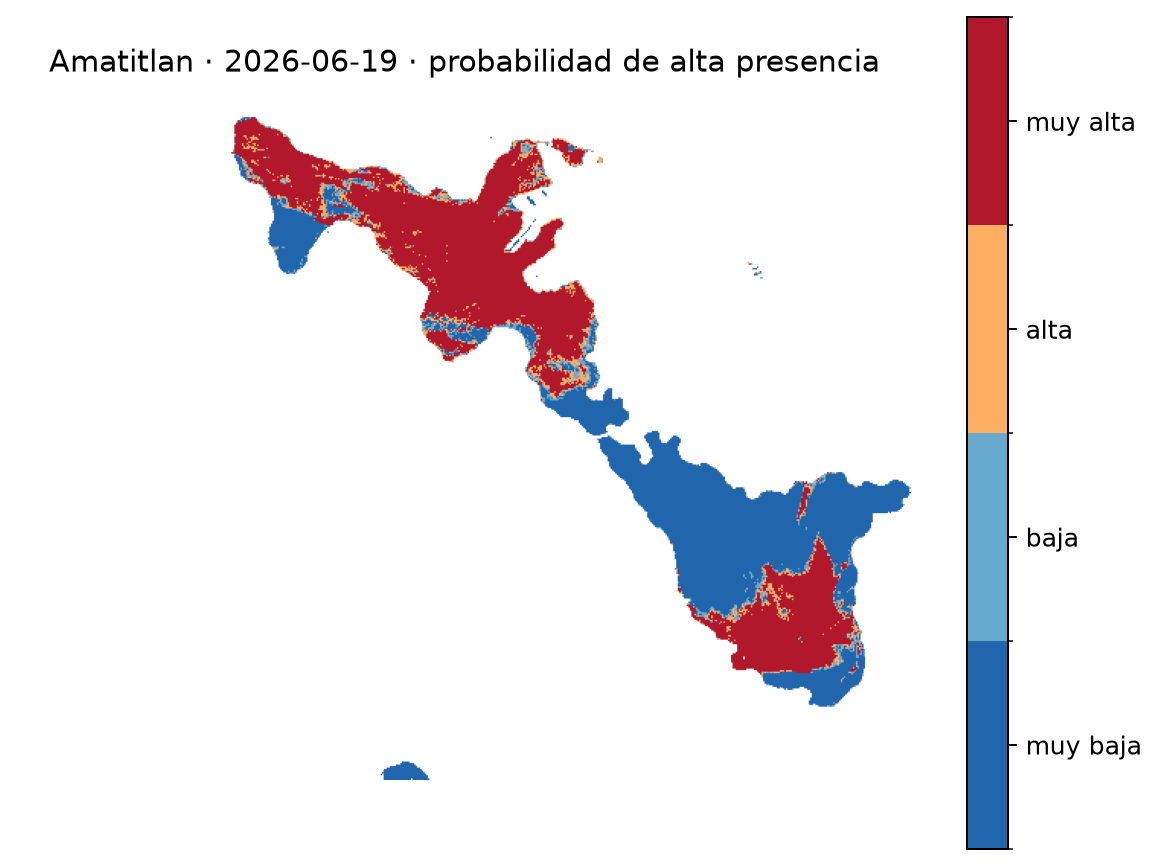

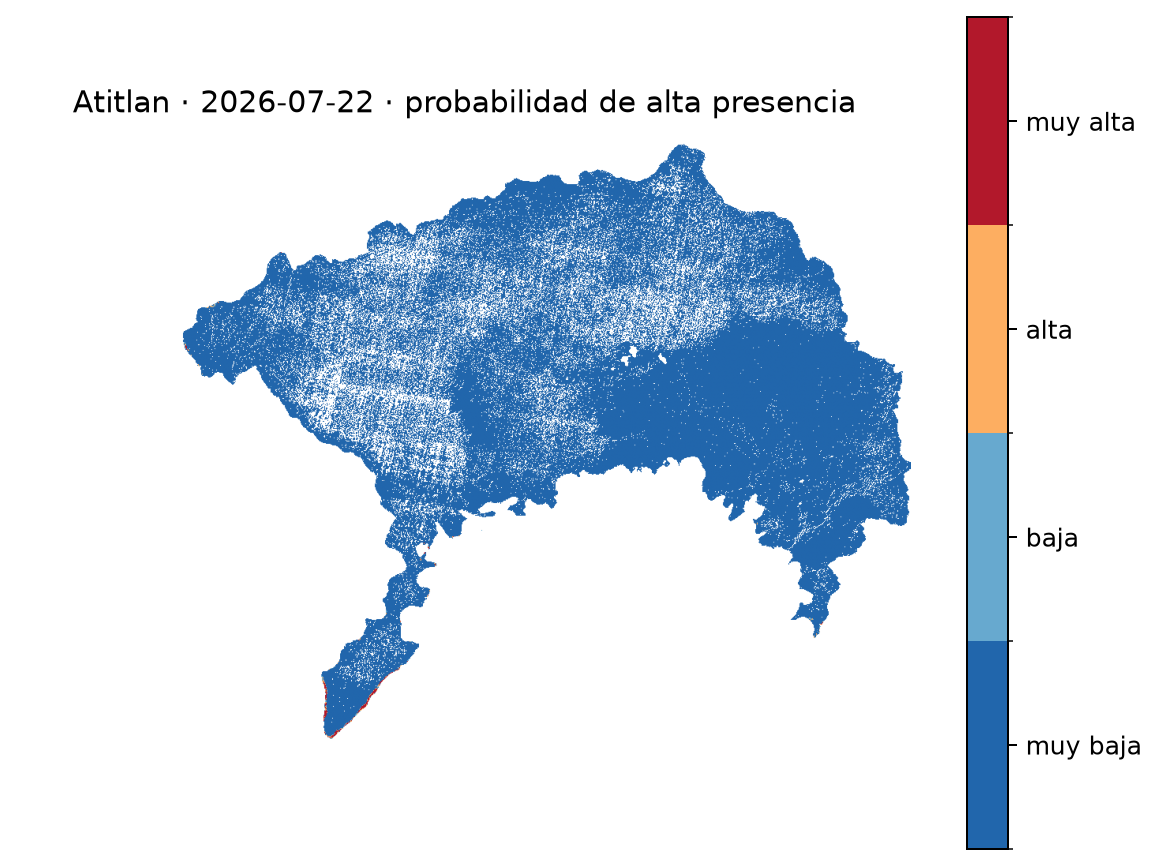

In [5]:
# Los artefactos se generan por el pipeline principal y se muestran si existen.
from IPython.display import display, Image
for p in sorted((ROOT/'outputs/parte2/figures').glob('*.png')) + sorted((ROOT/'outputs/parte2/maps').glob('*.png')):
    display(Image(filename=str(p)))

## Ejercicio 10 · Análisis y conclusiones
Las conclusiones finales se generan desde las métricas ejecutadas. Se comparan dependencia espacial/temporal, cambio de dominio y costos de falsos negativos y falsos positivos. No se declara aptitud operativa sin validación de campo.